# Test 1: Isolated Controller and Signal
Use a modified IEEE 14-bus setup with a VSM grid-forming inverter (REGF2) replacing synchronous generator 3 (GENROU_3). 

In [5]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets

print(test_case_dir)

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/test_cases


In [6]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import andes
from statsmodels.regression.rolling import RollingOLS


andes.config_logger(stream_level=30)

import new file (pls pls work)

In [7]:
case_path = andes.get_case(test_case_dir / "test_case_simplified.xlsx")
ss_ref = andes.load(case_path)

ss_ref.PFlow.run()

gen_idxs = list(ss_ref.GENROU.idx.v)
gen_buses = list(ss_ref.GENROU.bus.v)
M_base = ss_ref.GENROU.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": gen_idxs, "bus": gen_buses, "M": M_base})
gen_info.sort_values("M", ascending=False)


,gen_idx,bus,M
0,GENROU_2,2,4.0
1,GENROU_3,3,4.0


In [8]:
regf2_idxs = list(ss_ref.REGF2.idx.v)
regf2_buses = list(ss_ref.REGF2.bus.v)
#regf2_M_base = ss_ref.REGF2.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": regf2_idxs, "bus": regf2_buses, "mf": ss_ref.REGF2.mf.v})
gen_info.sort_values("gen_idx", ascending=False)

,gen_idx,bus,mf
0,1,1,10.0


## Set Up Fault and Run TDS
Trip the synchronous generator with the highest inertia (GENROU 2) at t = 1s.  $\alpha$ (inertia scaling) set to lowest (0.15). 

In [9]:
add_idx = "PQ_3" # add a load, causing a disturbance

# inertia_scales = [1.0, 0.7, 0.5, 0.4, 0.3, 0.2, 0.15] just testing lowest
# alpha = 0.15

ss = andes.load(case_path, setup=False)
ss.add("Toggle", model="PQ", dev=add_idx, t=1.0) # add the load @ t=1s
ss.setup()
ss.config.warn_abnormal = 0
ss.GENROU.M.v[:] = M_base

ss.PFlow.run()
ss.TDS.config.tf = 8
ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 0 # ignore stability criteria (run until end of simulation time)

ss.TDS.run()

results = ss.TDS.get_timeseries(ss.GENROU.omega)

## Results

### COI Frequency

          GENROU_2  GENROU_3
0.000000  1.000000  1.000000
0.033333  1.000000  1.000000
0.066667  1.000000  1.000000
0.100000  1.000000  1.000000
0.133333  1.000000  1.000000
...            ...       ...
7.866767  0.999999  0.999999
7.900100  1.000001  1.000001
7.933433  1.000002  1.000002
7.966767  1.000003  1.000003
8.000000  1.000004  1.000004

[243 rows x 2 columns]


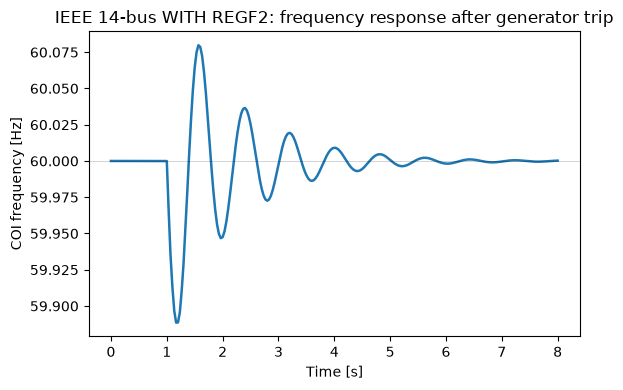

In [10]:
# plotting
weights = M_base / M_base.sum()
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

print(results)

f_coi = (results.values * weights).sum(axis=1) * 60
ax.plot(results.index, f_coi, color="tab:blue", linewidth=1.8)

ax.set_xlabel("Time [s]")
ax.set_ylabel("COI frequency [Hz]")
ax.set_title("IEEE 14-bus WITH REGF2: frequency response after generator trip")
#ax.set_xlim(0.0, 5.0)
ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)

plt.tight_layout()

### Nadir & RoCoF

In [11]:
f_coi = (results.values * weights).sum(axis=1) * 60
t = results.index.values

nadir = f_coi[t > 1.0].min()

post = (t >= 1.0) & (t <= 2.0)
t_post, f_post = t[post], f_coi[post]
rocof = np.max(np.abs(np.diff(f_post) / np.diff(t_post)))

print("Nadir: " + str(nadir))
print ("RoCoF: " + str(rocof))

Nadir: 59.88854462080164
RoCoF: 1.0263126744403164


### Voltages

In [12]:
voltage_df = ss.TDS.get_timeseries(ss.Bus.v)
print(f"Voltage DataFrame shape: {voltage_df.shape}")
print(f"Columns (bus indices): {list(voltage_df.columns)}")

Voltage DataFrame shape: (243, 5)
Columns (bus indices): [1, 2, 3, 4, 0]


(0.0, 5.0)

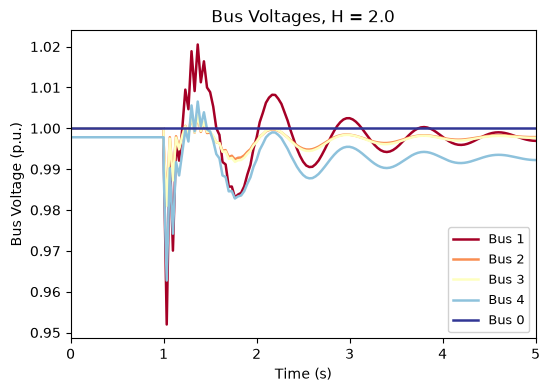

In [13]:
# Voltage at All Buses
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, bus in enumerate(voltage_df.columns):
    color = cmap(i / (len(voltage_df.columns) - 1))

    ax.plot(voltage_df.index, voltage_df[bus], color=color, linewidth=1.8,
            label=f"Bus {bus}")

H = np.average(M_base) / 2

ax.set_xlabel("Time (s)")
ax.set_ylabel("Bus Voltage (p.u.)")
ax.set_title(f"Bus Voltages, H = {H}")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.0, 5.0)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


### Power Delivered
Report delivered power (as measured by controller signal)

In [14]:
power_regf2_df = ss.TDS.get_timeseries(ss.REGF2.Pe)
power_regf2_df

,1
0.000000,0.400000
0.033333,0.400000
0.066667,0.400000
0.100000,0.400000
0.133333,0.400000
...,...
7.866767,0.399736
7.900100,0.399727
7.933433,0.399737
7.966767,0.399763


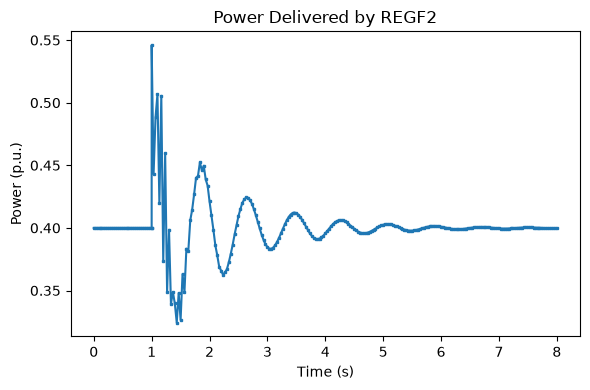

In [15]:
# --- power delivered by REGF2 ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"Power Delivered by REGF2")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (p.u.)")

# plot actual
ax.plot(power_regf2_df.index, power_regf2_df, "s-", color="tab:blue",
        markersize=1.8)

plt.tight_layout()

(0.0, 5.0)

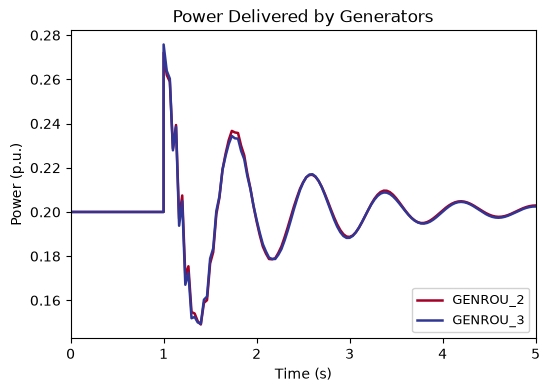

In [16]:
# Power Delivered by Generators
generator_power_df = ss.TDS.get_timeseries(ss.GENROU.Pe)
#print(generator_power_df)

cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, gen in enumerate(generator_power_df.columns):
    color = cmap(i / (len(generator_power_df.columns) - 1))

    ax.plot(generator_power_df.index, generator_power_df[gen], color=color, linewidth=1.8,
            label=f"{gen}")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (p.u.)")
ax.set_title("Power Delivered by Generators")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.0, 5.0)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


### RoCoF
Get RoCoF at Bus 1 using a BusROCOF object.

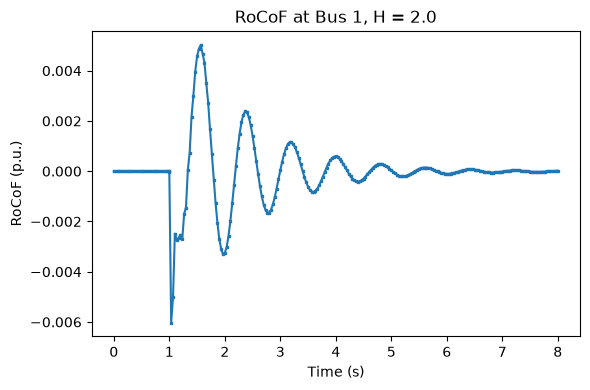

In [17]:
rocof_pu = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)

fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"RoCoF at Bus 1, H = {H}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("RoCoF (p.u.)")

# plot actual
ax.plot(rocof_pu.index, rocof_pu, "s-", color="tab:blue",
        markersize=1.8)

plt.tight_layout()

# Calculations
Calculate effective inertia constant H from power delivered.

In [18]:
f_0 = 60 # Hz
S_n = ss.REGF2.get("Sn", 1)
P_syn = -1 * power_regf2_df # power (p.u.)

In [19]:
P_syn[1]

0.000000   -0.400000
0.033333   -0.400000
0.066667   -0.400000
0.100000   -0.400000
0.133333   -0.400000
              ...   
7.866767   -0.399736
7.900100   -0.399727
7.933433   -0.399737
7.966767   -0.399763
8.000000   -0.399803
Name: 1, Length: 243, dtype: float64

In [16]:
# calculations (PER UNIT)
H_refg2_eff = (0.5 * P_syn[1].div(rocof_pu["BusROCOF_1"]))
H_refg2_eff
                           

0.000000            -inf
0.033333            -inf
0.066667            -inf
0.100000            -inf
0.133333            -inf
                ...     
7.866767    2.277827e+04
7.900100    1.853077e+04
7.933433    1.711942e+04
7.966767    1.749804e+04
8.000000    1.974818e+04
Length: 243, dtype: float64

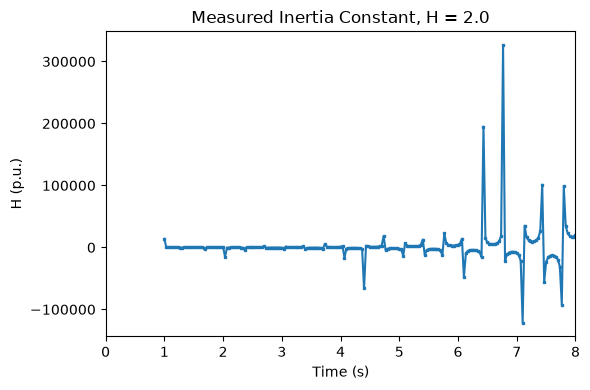

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"Measured Inertia Constant, H = {H}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (p.u.)")

# plot actual
ax.plot(H_refg2_eff.index, H_refg2_eff, "s-", color="tab:blue",
        markersize=1.8)

plt.xlim(0, 8)
#plt.ylim(-50, 50)
plt.tight_layout()

# Metrics
1. Pref, Pref0, Psyn
2. Peak Inertial Power
3. Response Delay (or settling time)
4. H_error  H(t) = (H_estimated - H_nominal)
    -  maybe calculate RMSE
5. Frequency Nadir
6. Maximum RoCoF

In [21]:
metrics_df = pd.DataFrame({
    "Run": [],
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power (MVA)": [],
    "H_RMSE": [],
    "Max RoCoF (Hz/s)":[],
    "Nadir (Hz)":[],
    "Settling Time (s)":[]
})
metrics_df.set_index("Run")
metrics_df

,Run,Tr (s),Pref,Peak Inertial Power (MVA),H_RMSE,Max RoCoF (Hz/s),Nadir (Hz),Settling Time (s)


In [49]:
run = 0

# conversion
S_n = ss.REGF2.get("Sn", 1)
f_0 = 60 #Hz

Tr = ss.REGF2.get("Tr", 1) # nominal
peak_inertial_power = np.max(power_regf2_df) * S_n  # nominal
max_rocof = np.max(rocof_pu) * f_0  # nominal
freq_nadir = np.min(ss.TDS.get_timeseries(ss.BusROCOF.f)) * f_0  # nominal

p_avail = ss.REGF2.get("Pmax", 1) # pu
p_ref = ss.PV.get("p0", 1) # pu
# p_ref0 = ss.PV.get("p0", 1)

#row = [run, Tr, peak_inertial_power, max_rocof, freq_nadir]
#metrics_df.loc[len(metrics_df)] = row
metrics_df

,Run,Tr (s),Pref,Peak Inertial Power (MVA),H_RMSE,Max RoCoF (Hz/s),Nadir (Hz),Settling Time (s)


## Calculate a Smooth H 

In [50]:
deltaP = power_regf2_df.subtract(p_ref)
tds_df = pd.concat([deltaP, rocof_pu], axis=1)
tds_df.columns = ["Delta P (pu)", "RoCoF (pu)"]

tds_df

,Delta P (pu),RoCoF (pu)
0.000000,0.000000,0.000000
0.033333,0.000000,0.000000
0.066667,0.000000,0.000000
0.100000,0.000000,0.000000
0.133333,0.000000,0.000000
...,...,...
7.866767,-0.000264,0.000004
7.900100,-0.000273,0.000009
7.933433,-0.000263,0.000013
7.966767,-0.000237,0.000016


In [51]:
window = 18 # ANDES step time = 1/30s, so to get a 200ms window is 6 steps
slope = tds_df['Delta P (pu)'].rolling(window).cov(tds_df['RoCoF (pu)']) / tds_df['RoCoF (pu)'].rolling(window).var()
H_t = -slope / 2

tds_df.loc[:,"H (s)"] = H_t
tds_df

,Delta P (pu),RoCoF (pu),H (s)
0.000000,0.000000,0.000000,NaN
0.033333,0.000000,0.000000,NaN
0.066667,0.000000,0.000000,NaN
0.100000,0.000000,0.000000,NaN
0.133333,0.000000,0.000000,NaN
...,...,...,...
7.866767,-0.000264,0.000004,1.235503
7.900100,-0.000273,0.000009,1.654242
7.933433,-0.000263,0.000013,2.942617
7.966767,-0.000237,0.000016,4.525175


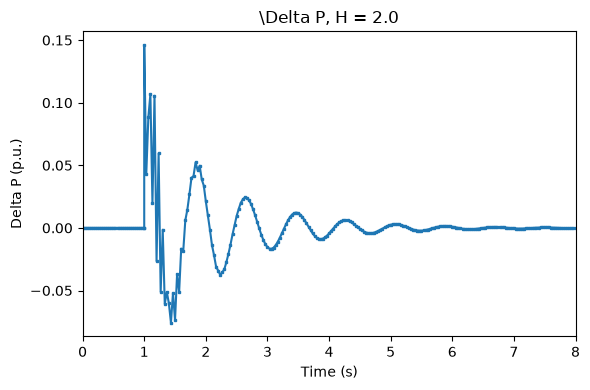

In [52]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"\Delta P, H = {H}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Delta P (p.u.)")

# plot actual
ax.plot(deltaP.index, deltaP, "s-", color="tab:blue",
        markersize=1.8)

plt.xlim(0, 8)
#plt.ylim(-50, 50)
plt.tight_layout()

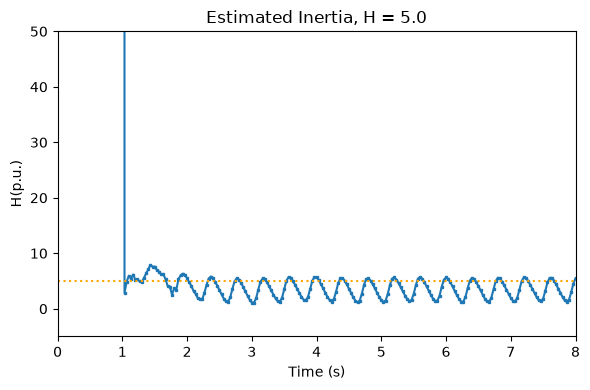

In [53]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1) * 0.5

ax.set_title(f"Estimated Inertia, H = {H_gfm}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("H(p.u.)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:blue",
        markersize=1.8)

plt.axline((0, H_gfm), slope=0, color="orange", linestyle=":", label="Point & Slope")

plt.xlim(0, 8)
plt.ylim(-5, 50)
plt.tight_layout()